Calculate energy density using the jumag package

In [ ]:
using NPZ
using MicroMagnetic

const Nx = 136
const Ny = 136
const Nz = 111
const Dx = 1.06e-9
const Dy = 1.06e-9
const Dz = 1.06e-9

const Ms_val = 3.84e5             
const A = 4.75e-12
const D_normal = 8.53e-4          
const R_cyl = 72.1e-9          

const Damage_depth_cells = 16      
const Damage_depth = Damage_depth_cells * Dz 

function get_xy_coords(i::Int, j::Int, dx::Float64, dy::Float64)
    x = (i - (Nx + 1) / 2) * dx
    y = (j - (Ny + 1) / 2) * dy
    return x, y
end

function get_z_coord(k::Int, dz::Float64)
    z = (k - 1 + 0.5) * dz
    return z
end

function Ms_fun(i, j, k, dx, dy, dz)
    x, y = get_xy_coords(i, j, dx, dy)

    if x^2 + y^2 < R_cyl^2
        return Ms_val
    end
    return 0.0
end 

function DMI_fun(i, j, k, dx, dy, dz)
    x, y = get_xy_coords(i, j, dx, dy)
    z = get_z_coord(k, dz)
    Lz = Nz * dz 
    
    r_sq = x^2 + y^2
 
    if r_sq < R_cyl^2 
        r = sqrt(r_sq)
        radial_damage = R_cyl - r < Damage_depth 
        top_damage = Lz - z < Damage_depth 
        bottom_damage = z < Damage_depth 

        if radial_damage || top_damage || bottom_damage
            return 0.0
        else
            return D_normal 
        end
    end
    return 0.0
end 

function DMI2_fun(i, j, k, dx, dy, dz)
    d_val = DMI_fun(i, j, k, dx, dy, dz)
    if d_val > 0.0
        return -D_normal
    end
    return 0.0
end

mesh = FDMesh(; dx=Dx, dy=Dy, dz=Dz, nx=Nx, ny=Ny, nz=Nz);
sim = Sim(mesh; driver="SD")

set_Ms(sim, Ms_fun)
ex = add_exch(sim, A)
dmi = add_dmi(sim, DMI_fun)
# dmi2 = add_dmi(sim, DMI2_fun)
d = add_demag(sim)
m0 = npzread("/home/zhaoy/studio/target-skyrmion/zheng_pmdata/zfs_refin_pm/3dmi_loss/16_layers_loss/results/loss1.6e+01_wphi1.0e+07/spin.npy")
init_m0(sim, reshape(m0, length(m0)))

MicroMagnetic.effective_field(sim, sim.spin)

energy_ex = reshape(ex.energy, Nx, Ny, Nz)
npzwrite("exch.npy", energy_ex)

energy_dmi = reshape(dmi.energy, Nx, Ny, Nz)
npzwrite("dmi.npy", energy_dmi)

# energy_dmi2 = reshape(dmi2.energy, Nx, Ny, Nz)
# npzwrite("dmi2.npy", energy_dmi2)

energy_demag = reshape(d.energy, Nx, Ny, Nz)
npzwrite("demag.npy", energy_demag)

println("能量密度计算完成并已保存到 exch.npy, dmi.npy, dmi2.npy, demag.npy")

[ Info: MicroSim has been created.
[ Info: Exchange has been added.
[ Info: Bulk DMI has been added.


能量密度计算完成并已保存到 exch.npy, dmi.npy, dmi2.npy, demag.npy


Plotting energy density distribution using Python

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


Loading NPY files...
Data Shape: H=136, W=136, D=111
Detected Max Abs Value: 105.56
Dynamic Color Range Set to: ±110.0
Generating Radial Profiles...


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


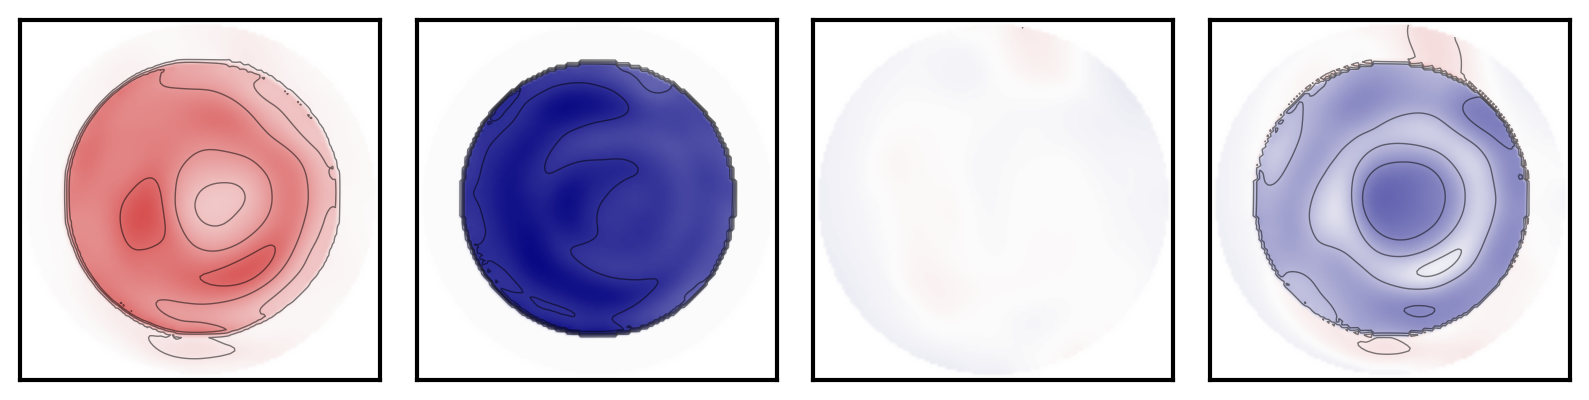

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

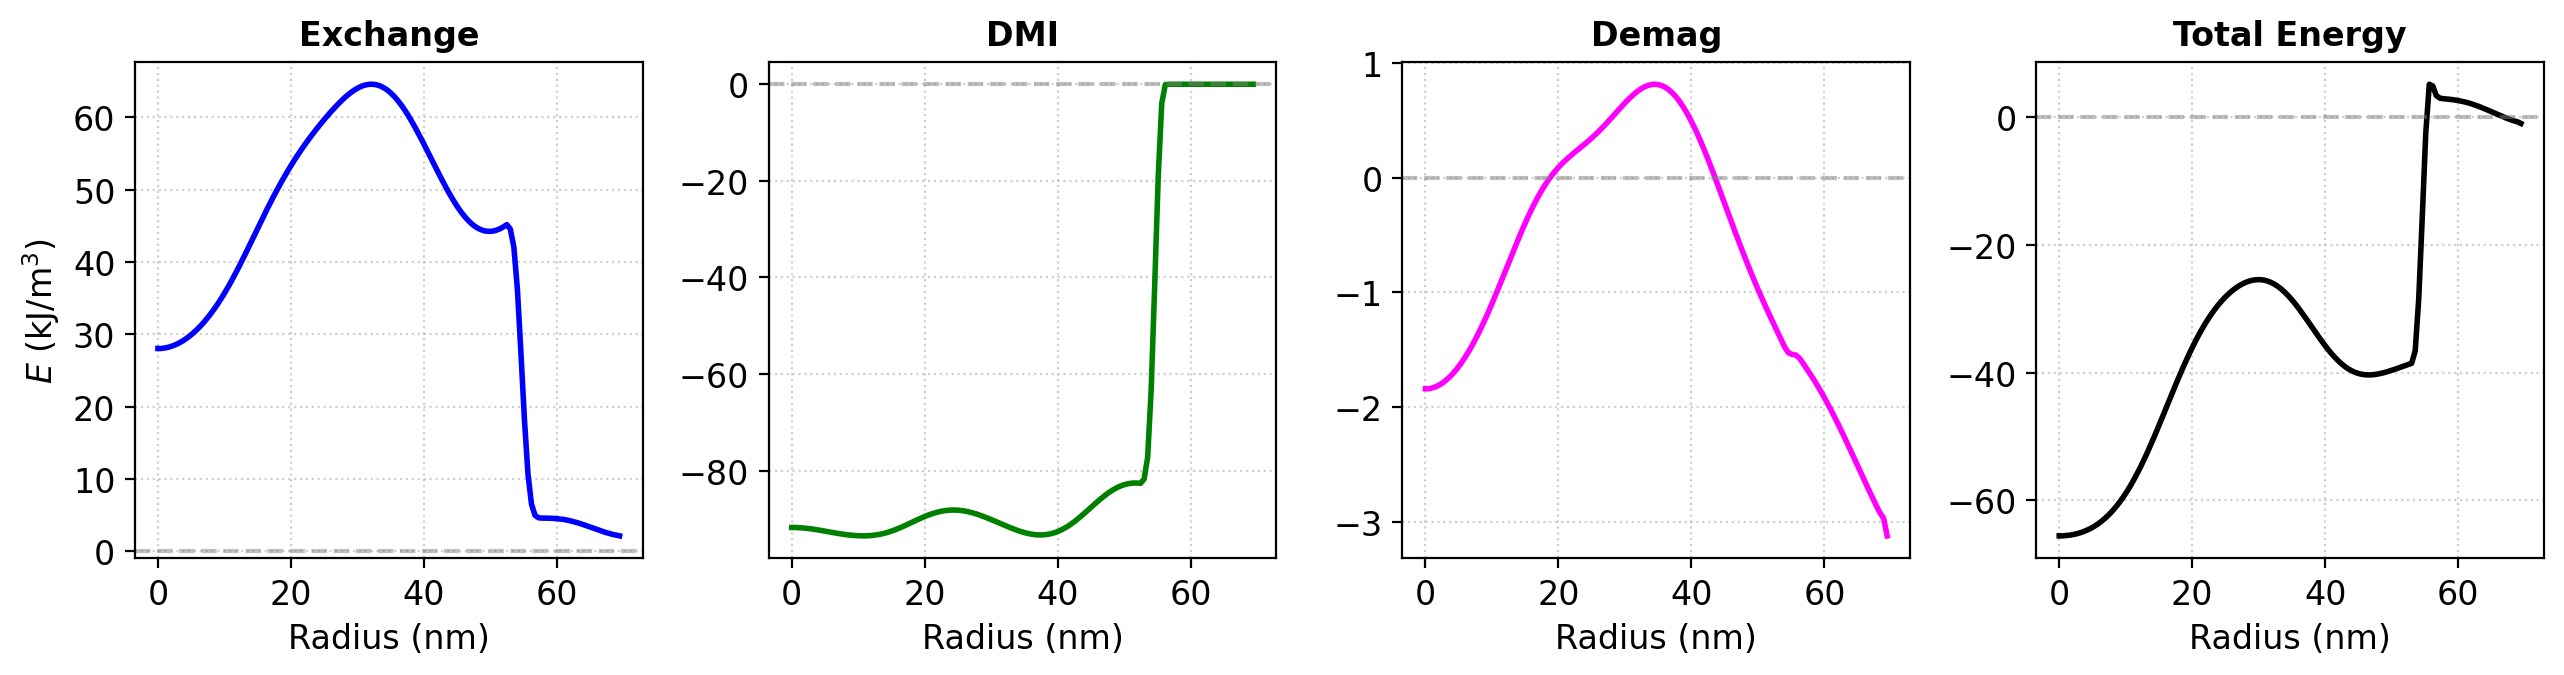

Radial profile data saved to radial_energy_layer55.csv


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import griddata 
from scipy.ndimage import map_coordinates
import pandas as pd 
import sys
import math

# Jupyter notebook specific config
try:
    from IPython import get_ipython
    if get_ipython() is not None:
        get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except ImportError:
    pass

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']  # 强制优先使用 Arial
plt.rcParams['axes.titlesize'] = 12  # 标题大小 (原~11 -> 24)
plt.rcParams['axes.labelsize'] = 12  # 轴标签大小 (原~9 -> 20)
plt.rcParams['xtick.labelsize'] = 12 # X轴刻度 (原~8 -> 16)
plt.rcParams['ytick.labelsize'] = 12 # Y轴刻度 (原~8 -> 16)
plt.rcParams['legend.fontsize'] = 12 # 图例大小
plt.rcParams['font.size'] = 12       # 全局基础字体

FILE_NAMES = ['exch.npy', 'dmi.npy', 'demag.npy']

CELL_SIZE = 1.06e-9       
NORMALIZATION_FACTOR = CELL_SIZE**3   

SLICE_INDEX = 55
RADIUS_PIXEL = 66         

def create_circular_mask(H, W, R):
    center_x = (W - 1) / 2.0
    center_y = (H - 1) / 2.0
    y_indices, x_indices = np.indices((H, W))
    distance_sq = (x_indices - center_x)**2 + (y_indices - center_y)**2
    return distance_sq <= R**2

def calculate_radial_profile_interpolated(data_2d, dx_meter, max_radius_pixel, num_angles=720):
    H, W = data_2d.shape
    cy, cx = (H - 1) / 2.0, (W - 1) / 2.0
    
    dr_pixel = 0.5 
    r_steps = np.arange(0, max_radius_pixel + dr_pixel, dr_pixel)
    theta = np.linspace(0, 2*np.pi, num_angles, endpoint=False)
    
    radial_mean = []
    r_axis_nm = []
    
    for r in r_steps:
        x_sample = cx + r * np.cos(theta)
        y_sample = cy + r * np.sin(theta)
        sampled_values = map_coordinates(data_2d, [y_sample, x_sample], order=1, mode='constant', cval=np.nan)
        valid_values = sampled_values[~np.isnan(sampled_values)]
        
        if len(valid_values) > 0:
            radial_mean.append(np.mean(valid_values))
            r_axis_nm.append(r * dx_meter * 1e9)
            
    return np.array(r_axis_nm), np.array(radial_mean)

if __name__ == "__main__":
    try:
        print("Loading NPY files...")
        raw_data_list = []
        for fname in FILE_NAMES:
            data = np.load(fname)
            raw_data_list.append(data / NORMALIZATION_FACTOR)
            
        H, W, D = raw_data_list[0].shape
        print(f"Data Shape: H={H}, W={W}, D={D}")
        
        if SLICE_INDEX >= D:
            print(f"Error: SLICE_INDEX {SLICE_INDEX} is out of bounds for depth {D}.")
            sys.exit()

        total_energy_3d = np.sum(raw_data_list, axis=0)
  
        mask_2d = create_circular_mask(H, W, RADIUS_PIXEL)
        mask_3d = np.tile(mask_2d[:, :, np.newaxis], (1, 1, D))
        
        exch_slice = np.where(mask_3d, raw_data_list[0], np.nan)[:, :, SLICE_INDEX] / 1000.0
        dmi_slice  = np.where(mask_3d, raw_data_list[1], np.nan)[:, :, SLICE_INDEX] / 1000.0
        demag_slice= np.where(mask_3d, raw_data_list[2], np.nan)[:, :, SLICE_INDEX] / 1000.0
        total_slice= np.where(mask_3d, total_energy_3d,  np.nan)[:, :, SLICE_INDEX] / 1000.0
        
        slices_to_plot = [exch_slice, dmi_slice, demag_slice, total_slice]
        plot_titles = ['Exchange', 'DMI', 'Demag', 'Total Energy']
        
        # ==========================================
        # 动态计算 VMAX (取5的倍数)
        # ==========================================
        all_values = np.array(slices_to_plot)
        max_abs_val = np.nanmax(np.abs(all_values))
        
        dynamic_limit = math.ceil(max_abs_val / 5.0) * 5.0
        if dynamic_limit == 0:
            dynamic_limit = 5.0
            
        vmax_kJm3 = dynamic_limit
        vmin_kJm3 = -dynamic_limit
        
        print(f"Detected Max Abs Value: {max_abs_val:.2f}")
        print(f"Dynamic Color Range Set to: ±{vmax_kJm3}")

    except Exception as e:
        print(f"❌ Data loading or processing failed: {e}")
        sys.exit()

    # 4. 定义 Colormap
    navy_blue = (0.0, 0.0, 0.5)  
    gray_mid = (0.99, 0.99, 0.99)   
    warm_red = (0.8, 0.1, 0.1)   
    
    colors = [navy_blue, gray_mid, warm_red]
    nodes = [0.0, 0.5, 1.0] 
    cmap_custom = LinearSegmentedColormap.from_list("navy_gray_red", list(zip(nodes, colors)))
    cmap_custom.set_bad('white') 

    # 5. 绘图 (修改为 1行4列)
    fig, axes = plt.subplots(1, 4, figsize=(10, 2.5), sharex=True, sharey=True) 
    plt.subplots_adjust(wspace=0.1, hspace=0.1)

    # 动态调整步长
    if vmax_kJm3 >= 100:
        step = 20
    elif vmax_kJm3 <= 15:
        step = 5
    else:
        step = 10
        
    contour_levels = np.arange(vmin_kJm3, vmax_kJm3 + 0.1, step)

    for i, data_2d in enumerate(slices_to_plot):
        ax = axes[i]
        
        # A. 热图
        heatmap = ax.imshow(data_2d, 
                            cmap=cmap_custom, 
                            aspect='equal', 
                            interpolation='gaussian',
                            vmin=vmin_kJm3, 
                            vmax=vmax_kJm3,
                            origin='lower') 

        # B. 等值线
        contours = ax.contour(data_2d, 
                              levels=contour_levels, 
                              colors='black', 
                              linewidths=0.5, 
                              alpha=0.5,
                              linestyles='solid',
                              origin='lower')
        
        #ax.set_title(plot_titles[i], pad=10) # 加上标题方便区分
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(1.5)
    #  # Colorbar (如果需要显示，取消注释)
    # cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
    # tick_values = np.linspace(vmin_kJm3, vmax_kJm3, 5)
    # cbar = fig.colorbar(heatmap, cax=cbar_ax, ticks=tick_values)
    # # cbar.ax.tick_params(labelsize=8)
    # cbar.set_ticklabels([f"{t:.0f}" for t in tick_values])
    # cbar.set_label('Energy density (kJ/m³)', labelpad=5) 
    # plt.show()

    # 6. 计算径向分布并保存 (修改为 1行4列)
    print("Generating Radial Profiles...")
    
    fig2, axes2 = plt.subplots(1, 4, figsize=(13, 3.5), sharex=True)
    # 增加 Demag 的颜色 (品红)
    line_colors = ['blue', 'green', 'magenta', 'black'] 
    
    data_to_save = {}
    dx = CELL_SIZE 
    
    for i, data_2d in enumerate(slices_to_plot):
        r_nm, energy_profile = calculate_radial_profile_interpolated(data_2d, dx, RADIUS_PIXEL, num_angles=720)
        
        col_name = plot_titles[i]
        if i == 0: data_to_save['Radius (nm)'] = r_nm
        data_to_save[f"{col_name} (kJ/m3)"] = energy_profile
        
        ax = axes2[i]
        ax.plot(r_nm, energy_profile, color=line_colors[i], linewidth=2)
        ax.axhline(0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
        ax.set_title(col_name, fontweight='bold')
        ax.set_xlabel("Radius (nm)")
        if i == 0: ax.set_ylabel(r"$E$ (kJ/m$^3$)")
        ax.grid(True, which='both', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()
    
    out_csv = f"radial_energy_layer{SLICE_INDEX}.csv"
    pd.DataFrame(data_to_save).to_csv(out_csv, index=False)
    print(f"Radial profile data saved to {out_csv}")